# UV-Net style B-Rep → Face-Adjacency Graph (learning edition 😄)

This notebook shows how to convert a CAD **STEP** file into the graph representation used by **UV-Net (CVPR 2021)**:

- **Node = one B-Rep face**
- **Edge = adjacency between faces sharing a B-Rep edge**
- Nodes/edges carry sampled geometry grids (positions, normals/tangents, trim mask)

This is mainly for **exploration and learning** — I’m still figuring out CAD + ML workflows, so this notebook is part tutorial, part experiment.

If you’re wondering whether this is *vibecoded*: yes… **partly 😄**  
But I went through each step and understood the pipeline, so it’s not blindly generated — more like *assisted coding with comprehension*.

---

## What is a B-Rep (and why not just a mesh?)
A STEP file stores a **boundary representation (B-Rep)**: analytic surfaces/curves (planes, cylinders, NURBS, …) plus topology (which faces touch).  
A mesh is only an approximation. UV-Net uses B-Rep to preserve CAD structure.

---

## End Goal
Build a `dgl.DGLGraph` `graph`:

- `graph.num_nodes()` = #faces  
- `graph.num_edges()` = directed face adjacencies  
- `graph.ndata["x"]` → per-face features `(N*N*7)`  
- `graph.edata["x"]` → per-edge features `(N*6)`

**Face features:** `(x,y,z) + (nx,ny,nz) + trim mask`  
**Edge features:** `(x,y,z) + (tx,ty,tz)`  

`N` = UV resolution (UV-Net uses `N=10`).

---

## References
- Jayaraman et al., *UV-Net: Learning from Boundary Representations* (CVPR 2021)  
- https://github.com/AutodeskAILab/UV-Net

## 0. Imports & Configuration

This section loads the libraries used in the rest of the notebook:

- **OCP / OpenCASCADE**: reads STEP and lets us iterate faces/edges/vertices (the true B-Rep, not a mesh)
- **NumPy**: array storage and sampling grids
- **PyTorch**: stores the final features as tensors (`float32`), matching ML pipelines
- **DGL**: the graph container (`DGLGraph`) where nodes/edges have feature arrays (DGL = Deep Graph Library)
- **Matplotlib**: quick visual sanity checks

We also set a random seed so the sample selection and plots are repeatable.

In [ ]:
from __future__ import annotations

import random
from collections import defaultdict
from pathlib import Path

import dgl
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# Open CASCADE via cadquery-ocp
from OCP.BRep import BRep_Tool
from OCP.BRepAdaptor import BRepAdaptor_Curve, BRepAdaptor_Surface
from OCP.BRepCheck import BRepCheck_Analyzer
from OCP.BRepMesh import BRepMesh_IncrementalMesh
from OCP.IFSelect import IFSelect_RetDone
from OCP.STEPControl import STEPControl_Reader
from OCP.TopAbs import TopAbs_EDGE, TopAbs_FACE, TopAbs_SOLID, TopAbs_VERTEX
from OCP.TopExp import TopExp, TopExp_Explorer
from OCP.TopLoc import TopLoc_Location
from OCP.TopoDS import TopoDS, TopoDS_Shape
from OCP.TopTools import (
    TopTools_IndexedDataMapOfShapeListOfShape,
    TopTools_IndexedMapOfShape,
)

# ── Config ──
DATASET_ROOT = Path("mechcad/mechcad")
SEED = 42
UV_RESOLUTION = 10  # N×N grid for faces, N points for edges (UV-Net default)

random.seed(SEED)
np.random.seed(SEED)
print("All imports OK")

All imports OK


## 1. Pick One Random Sample per Class

The MechCAD dataset is organized as folders (classes), each containing STEP (`.stp`) files.

What we do here:
1. For each class folder, pick **one random STEP file**.
2. Display a small table so you can see what was chosen.
3. Pick **one** of those files as the single "working sample" for the rest of the notebook.

Why do this?
- It keeps the notebook fast and easy to follow.
- You still get a sense of variability across classes (via the table and later topology stats).

In [4]:
def load_step(path: str | Path) -> TopoDS_Shape:
    """Read a STEP file and return the TopoDS_Shape."""
    reader = STEPControl_Reader()
    if reader.ReadFile(str(path)) != IFSelect_RetDone:
        raise RuntimeError(f"Cannot read {path}")
    reader.TransferRoots()
    shape = reader.OneShape()
    if shape.IsNull():
        raise RuntimeError(f"Null shape: {path}")
    return shape


# Gather one random file per class
rng = random.Random(SEED)
samples = []
for cls_dir in sorted(DATASET_ROOT.iterdir()):
    if not cls_dir.is_dir():
        continue
    files = sorted(cls_dir.glob("*.stp"))
    if files:
        f = rng.choice(files)
        samples.append({"label": cls_dir.name, "path": str(f), "file": f.name})

samples_df = pd.DataFrame(samples)
display(samples_df)

# Pick the first sample for the single-sample walkthrough
sample = samples[0]
shape = load_step(sample["path"])
print(f"\nWorking sample: {sample['label']}/{sample['file']}")

,label,path,file
0,bearing,mechcad\mechcad\bearing\210.stp,210.stp
1,bolt,mechcad\mechcad\bolt\1043.stp,1043.stp
2,bracket,mechcad\mechcad\bracket\495.stp,495.stp
3,coupling,mechcad\mechcad\coupling\486.stp,486.stp
4,flange,mechcad\mechcad\flange\200.stp,200.stp
5,gear,mechcad\mechcad\gear\218.stp,218.stp
6,nut,mechcad\mechcad\nut\769.stp,769.stp
7,pulley,mechcad\mechcad\pulley\264.stp,264.stp
8,screw,mechcad\mechcad\screw\717.stp,717.stp
9,shaft,mechcad\mechcad\shaft\223.stp,223.stp



Working sample: bearing/210.stp


## 2. Visualize the STEP Model (3-D Tessellation)

A STEP/B-Rep model is *not* a triangle mesh. For visualization, we temporarily **tessellate** each face (turn it into triangles) and plot the triangles.

Important mental model:
- The tessellation is only for plotting and sanity-checking.
- The learning representation we build later uses the **original B-Rep surfaces and curves**, sampled in parameter space.

Key API used:
- `BRepMesh_IncrementalMesh`: asks OpenCASCADE to generate triangles on each face (controlled by a deflection parameter).

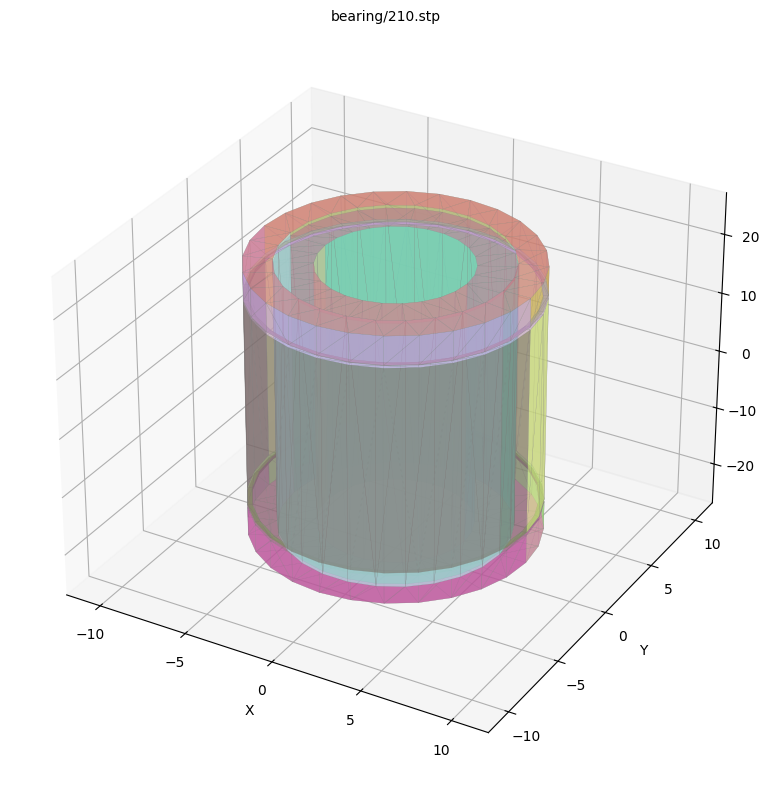

In [5]:
def tessellate_shape(shape: TopoDS_Shape, deflection: float = 0.1):
    """Return list-of-lists of triangles, one list per face."""
    BRepMesh_IncrementalMesh(shape, deflection, False, 0.5, True)
    face_tris = []
    exp = TopExp_Explorer(shape, TopAbs_FACE)
    while exp.More():
        face = TopoDS.Face_s(exp.Current())
        loc = TopLoc_Location()
        tri = BRep_Tool.Triangulation_s(face, loc)
        trsf = loc.Transformation()
        tris = []
        if tri is not None:
            for i in range(1, tri.NbTriangles() + 1):
                n1, n2, n3 = tri.Triangle(i).Get()
                pts = [tri.Node(n).Transformed(trsf) for n in (n1, n2, n3)]
                tris.append([[p.X(), p.Y(), p.Z()] for p in pts])
        face_tris.append(tris)
        exp.Next()
    return face_tris


def render_shape(shape, title="", ax=None):
    """Render the tessellated shape with randomly colored faces."""
    face_tris = tessellate_shape(shape)
    if ax is None:
        fig = plt.figure(figsize=(8, 8))
        ax = fig.add_subplot(111, projection="3d")
    rng_c = random.Random(0)
    all_pts = []
    for tris in face_tris:
        color = [rng_c.random() * 0.6 + 0.3 for _ in range(3)] + [0.6]
        if tris:
            ax.add_collection3d(
                Poly3DCollection(tris, alpha=0.6, facecolor=color,
                                 edgecolor="gray", linewidth=0.15)
            )
            for t in tris:
                all_pts.extend(t)
    if all_pts:
        pts = np.array(all_pts)
        margin = 0.1 * (pts.max() - pts.min())
        for i, lab in enumerate("XYZ"):
            getattr(ax, f"set_{lab.lower()}lim")(
                pts[:, i].min() - margin, pts[:, i].max() + margin
            )
            getattr(ax, f"set_{lab.lower()}label")(lab)
    ax.set_title(title, fontsize=10)
    return ax


fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")
render_shape(shape, title=f"{sample['label']}/{sample['file']}", ax=ax)
plt.tight_layout()
plt.show()

## 3. Quick B-Rep Topology EDA

A B-Rep has:
- **Faces**: surface patches (these will become **graph nodes**)
- **Edges**: curve segments bounding faces (shared edges induce **graph adjacency**)
- **Vertices**: endpoints of edges
- **Solids**: disconnected solid bodies (a STEP file can contain more than one)

We count these for:
- The working sample (so you know what size graph to expect)
- One random part per class (so you see typical sizes across classes)

Rule of thumb you will see later:
- `#graph_nodes == #faces`

In [6]:
def count_topo(shape: TopoDS_Shape) -> dict:
    """Count B-Rep sub-shape elements."""
    counts = {}
    for name, flag in [("faces", TopAbs_FACE), ("edges", TopAbs_EDGE),
                       ("vertices", TopAbs_VERTEX), ("solids", TopAbs_SOLID)]:
        exp, n = TopExp_Explorer(shape, flag), 0
        while exp.More():
            n += 1; exp.Next()
        counts[name] = n
    return counts


# Single sample
topo = count_topo(shape)
print(f"Working sample topology: {topo}")

# All 10 one-per-class samples
rows = []
for s in samples:
    sh = load_step(s["path"])
    rows.append({"label": s["label"], "file": s["file"], **count_topo(sh)})
topo_df = pd.DataFrame(rows)
display(topo_df)

print("\nSummary statistics:")
display(topo_df[["faces", "edges", "vertices"]].describe().round(1))

Working sample topology: {'faces': 24, 'edges': 96, 'vertices': 192, 'solids': 2}


,label,file,faces,edges,vertices,solids
0,bearing,210.stp,24,96,192,2
1,bolt,1043.stp,27,114,228,1
2,bracket,495.stp,50,276,552,1
3,coupling,486.stp,46,252,504,1
4,flange,200.stp,35,170,340,2
5,gear,218.stp,337,1906,3812,2
6,nut,769.stp,21,186,372,1
7,pulley,264.stp,145,802,1604,1
8,screw,717.stp,246,1312,2770,2
9,shaft,223.stp,468,2384,4768,11



Summary statistics:


,faces,edges,vertices
count,10.0,10.0,10.0
mean,139.9,749.8,1514.2
std,158.5,835.6,1682.7
min,21.0,96.0,192.0
25%,29.0,174.0,348.0
50%,48.0,264.0,528.0
75%,220.8,1184.5,2478.5
max,468.0,2384.0,4768.0


## 4. Validity Sanity Check

Before building ML features, it is worth checking that each B-Rep is "healthy". This prevents confusing failures later.

This section checks:
- **Topological validity** with `BRepCheck_Analyzer` (basic CAD integrity)
- **Non-manifold edges**: edges shared by more than 2 faces
  - In many CAD datasets you expect mostly manifold geometry; lots of non-manifold edges can indicate a problematic model or a special case.

Interpreting the output:
- `valid=True` and `non_manifold=0` is the cleanest case.
- `WARN` is not automatically wrong, but it is a sign the sample may be harder for graph building / learning.

In [7]:
def check_brep(shape: TopoDS_Shape) -> dict:
    """Basic B-Rep validity checks."""
    valid = BRepCheck_Analyzer(shape).IsValid()

    # Non-manifold edges (shared by >2 faces)
    emap = TopTools_IndexedDataMapOfShapeListOfShape()
    TopExp.MapShapesAndAncestors_s(shape, TopAbs_EDGE, TopAbs_FACE, emap)
    non_manifold = sum(
        1 for i in range(1, emap.Extent() + 1)
        if emap.FindFromIndex(i).Extent() > 2
    )
    return {"brep_valid": valid, "non_manifold_edges": non_manifold}


for s in samples:
    sh = load_step(s["path"])
    ck = check_brep(sh)
    status = "OK" if ck["brep_valid"] and ck["non_manifold_edges"] == 0 else "WARN"
    print(f"[{status}] {s['label']}/{s['file']}  valid={ck['brep_valid']}  "
          f"non-manifold={ck['non_manifold_edges']}")

[OK] bearing/210.stp  valid=True  non-manifold=0
[OK] bolt/1043.stp  valid=True  non-manifold=0
[OK] bracket/495.stp  valid=True  non-manifold=0
[OK] coupling/486.stp  valid=True  non-manifold=0
[OK] flange/200.stp  valid=True  non-manifold=0
[OK] gear/218.stp  valid=True  non-manifold=0
[OK] nut/769.stp  valid=True  non-manifold=0
[OK] pulley/264.stp  valid=True  non-manifold=0
[OK] screw/717.stp  valid=True  non-manifold=0
[OK] shaft/223.stp  valid=True  non-manifold=0


## 5. UV-Grid Sampling Functions (the core UV-Net representation)

UV-Net does **not** feed raw CAD entities directly into a network. Instead, it samples small, fixed-size grids so every face/edge becomes a tensor with a consistent shape.

### 5.1 Face (surface) sampling: an `N x N` grid in (u, v)
Every B-Rep face is a parametric surface:

$$S(u,v) \rightarrow (x,y,z)$$

So we can choose a grid of `(u,v)` values and evaluate the surface there.

For each grid point we store 7 channels:

| Channels | Count | Meaning |
|---|---:|---|
| position | 3 | surface point `(x,y,z)` |
| normal | 3 | surface normal `(nx,ny,nz)` |
| trim mask | 1 | `1` if the `(u,v)` sample lies inside/on the trimmed face boundary, else `0` |

So the per-face tensor is shape **`(N, N, 7)`**.

Why do we need the trim mask?
- CAD faces are often **trimmed**: the underlying surface may be infinite (a plane), but the face is only a bounded patch.
- The trim mask tells the network which samples correspond to the actual face region.

In this notebook, the trim mask is computed using OpenCASCADE's 2D face classifier (`BRepTopAdaptor_FClass2d`) and we treat `TopAbs_IN` and `TopAbs_ON` as "inside".

### 5.2 Edge (curve) sampling: `N` samples along a curve parameter `t`
Every B-Rep edge is a parametric curve:

$$C(t) \rightarrow (x,y,z)$$

For each of the `N` samples we store 6 channels:

| Channels | Count | Meaning |
|---|---:|---|
| position | 3 | curve point `(x,y,z)` |
| tangent | 3 | curve tangent direction `(tx,ty,tz)` |

So the per-edge tensor is shape **`(N, 6)`**.

### 5.3 How this matches UV-Net
UV-Net's released preprocessing produces exactly these channel counts:
- faces: `N x N x 7`
- edges: `N x 6`

In [8]:
from OCP.BRepLProp import BRepLProp_CLProps, BRepLProp_SLProps
from OCP.BRepTopAdaptor import BRepTopAdaptor_FClass2d
from OCP.TopAbs import TopAbs_IN, TopAbs_ON
from OCP.gp import gp_Dir, gp_Pnt2d


def sample_face_uv_grid(face, N: int = 10) -> np.ndarray:
    """
    Sample an NxN UV-grid on a B-Rep face.
    Returns array of shape (N, N, 7): [x,y,z, nx,ny,nz, trim_mask].
    """
    adaptor = BRepAdaptor_Surface(face, True)
    u0, u1 = adaptor.FirstUParameter(), adaptor.LastUParameter()
    v0, v1 = adaptor.FirstVParameter(), adaptor.LastVParameter()

    # Clamp large parametric domains (e.g. infinite planes)
    MAX_RANGE = 1000.0
    u0, u1 = max(u0, -MAX_RANGE), min(u1, MAX_RANGE)
    v0, v1 = max(v0, -MAX_RANGE), min(v1, MAX_RANGE)

    us = np.linspace(u0, u1, N)
    vs = np.linspace(v0, v1, N)
    classifier = BRepTopAdaptor_FClass2d(face, 1e-6)

    grid = np.zeros((N, N, 7), dtype=np.float32)
    for i, u in enumerate(us):
        for j, v in enumerate(vs):
            pnt = adaptor.Value(u, v)
            grid[i, j, 0:3] = [pnt.X(), pnt.Y(), pnt.Z()]

            props = BRepLProp_SLProps(adaptor, u, v, 1, 1e-6)
            if props.IsNormalDefined():
                n = props.Normal()
                grid[i, j, 3:6] = [n.X(), n.Y(), n.Z()]

            state = classifier.Perform(gp_Pnt2d(u, v))
            grid[i, j, 6] = 1.0 if state in (TopAbs_IN, TopAbs_ON) else 0.0

    return grid


def sample_edge_uv_grid(edge, N: int = 10) -> np.ndarray:
    """
    Sample N points along a B-Rep edge curve.
    Returns array of shape (N, 6): [x,y,z, tx,ty,tz].
    """
    adaptor = BRepAdaptor_Curve(edge)
    t0, t1 = adaptor.FirstParameter(), adaptor.LastParameter()
    MAX_RANGE = 1000.0
    t0, t1 = max(t0, -MAX_RANGE), min(t1, MAX_RANGE)

    ts = np.linspace(t0, t1, N)
    grid = np.zeros((N, 6), dtype=np.float32)
    for i, t in enumerate(ts):
        pnt = adaptor.Value(t)
        grid[i, 0:3] = [pnt.X(), pnt.Y(), pnt.Z()]
        props = BRepLProp_CLProps(adaptor, t, 1, 1e-6)
        if props.IsTangentDefined():
            tangent = gp_Dir()
            props.Tangent(tangent)
            grid[i, 3:6] = [tangent.X(), tangent.Y(), tangent.Z()]
    return grid


# Quick test on first face & first edge
exp_f = TopExp_Explorer(shape, TopAbs_FACE)
test_face = TopoDS.Face_s(exp_f.Current())
face_grid = sample_face_uv_grid(test_face, UV_RESOLUTION)
print(f"Face UV-grid shape: {face_grid.shape}  (expect {UV_RESOLUTION}x{UV_RESOLUTION}x7)")

exp_e = TopExp_Explorer(shape, TopAbs_EDGE)
test_edge = TopoDS.Edge_s(exp_e.Current())
edge_grid = sample_edge_uv_grid(test_edge, UV_RESOLUTION)
print(f"Edge UV-grid shape: {edge_grid.shape}  (expect {UV_RESOLUTION}x6)")

Face UV-grid shape: (10, 10, 7)  (expect 10x10x7)
Edge UV-grid shape: (10, 6)  (expect 10x6)


## 6. Build the DGL Face-Adjacency Graph (UV-Net style)

Now we assemble the final representation used by UV-Net: a **face adjacency graph**.

### 6.1 What is the graph?
- **Node = a B-Rep face**
- **(Undirected) edge = two faces share a B-Rep edge**

In DGL, edges are stored as **directed**, so we insert both directions (`A -> B` and `B -> A`) for every shared B-Rep edge. That makes message passing in GNNs straightforward.

### 6.2 What features do we store?
We compute UV-grids using the sampling functions from the previous section, then store them as tensors:

- Node features (faces): `graph.ndata["x"]`
  - Original logical shape: `(num_faces, N, N, 7)`
  - Stored here as a flattened vector per face: `(num_faces, N*N*7)`

- Edge features (shared edges): `graph.edata["x"]`
  - Original logical shape: `(num_directed_edges, N, 6)`
  - Stored here as a flattened vector per directed edge: `(num_directed_edges, N*6)`

This flattening is just for convenience of storing in `DGLGraph`; you can reshape later when feeding a CNN.

### 6.3 Where this comes from in UV-Net
UV-Net constructs the same kind of DGL graph and stores features in `ndata["x"]` and `edata["x"]` during preprocessing.


In [9]:
def brep_to_dgl_graph(
    shape: TopoDS_Shape, N: int = 10
) -> tuple[dgl.DGLGraph, np.ndarray]:
    """
    Convert a B-Rep shape into a DGL face‑adjacency graph (UV‑Net style).

    Returns:
        g        : DGL graph with ndata['x'] and edata['x']
        centroids: (num_faces, 3) face centroids for visualization
    """
    # 1. Index faces
    face_map = TopTools_IndexedMapOfShape()
    exp = TopExp_Explorer(shape, TopAbs_FACE)
    while exp.More():
        face_map.Add(exp.Current())
        exp.Next()
    num_faces = face_map.Extent()

    # 2. Face UV‑grids (node features) + centroids
    node_feats, centroids = [], []
    for i in range(1, num_faces + 1):
        face = TopoDS.Face_s(face_map.FindKey(i))
        grid = sample_face_uv_grid(face, N)  # (N, N, 7)
        node_feats.append(grid.flatten())
        mask = grid[:, :, 6] > 0.5
        if mask.any():
            centroids.append(grid[:, :, 0:3][mask].mean(axis=0))
        else:
            centroids.append(grid[:, :, 0:3].mean(axis=(0, 1)))

    node_feats = np.stack(node_feats)
    centroids = np.array(centroids, dtype=np.float32)

    # 3. Build edges via shared B‑Rep edges
    edge_face_map = TopTools_IndexedDataMapOfShapeListOfShape()
    TopExp.MapShapesAndAncestors_s(shape, TopAbs_EDGE, TopAbs_FACE, edge_face_map)

    src, dst, edge_feats = [], [], []
    for i in range(1, edge_face_map.Extent() + 1):
        brep_edge = TopoDS.Edge_s(edge_face_map.FindKey(i))
        adj_list = edge_face_map.FindFromIndex(i)

        # PythonOCC makes this iterable — no .begin() / .end()
        fi_list = []
        for adjacent_shape in adj_list:
            fi = face_map.FindIndex(adjacent_shape)
            # Only consider valid face indices
            if fi > 0:
                fi_list.append(fi - 1)

        if len(fi_list) < 2:
            continue  # boundary edge

        egrid = sample_edge_uv_grid(brep_edge, N).flatten()  # (N*6,)

        # Add graph edges (bidirectional)
        for a in range(len(fi_list)):
            for b in range(a + 1, len(fi_list)):
                src.extend([fi_list[a], fi_list[b]])
                dst.extend([fi_list[b], fi_list[a]])
                edge_feats.extend([egrid, egrid])

    # 4. Construct DGL graph
    g = dgl.graph((src, dst), num_nodes=num_faces)
    g.ndata["x"] = torch.tensor(node_feats, dtype=torch.float32)
    if edge_feats:
        g.edata["x"] = torch.tensor(np.stack(edge_feats), dtype=torch.float32)
    else:
        g.edata["x"] = torch.zeros((0, N * 6), dtype=torch.float32)

    return g, centroids


# Build graph for the working sample
graph, centroids = brep_to_dgl_graph(shape, N=UV_RESOLUTION)
print(graph)
print(f"\nNode feature shape : {graph.ndata['x'].shape}")
print(f"Edge feature shape : {graph.edata['x'].shape}")
print(f"Centroids shape    : {centroids.shape}")

Graph(num_nodes=24, num_edges=96,
      ndata_schemes={'x': Scheme(shape=(700,), dtype=torch.float32)}
      edata_schemes={'x': Scheme(shape=(60,), dtype=torch.float32)})

Node feature shape : torch.Size([24, 700])
Edge feature shape : torch.Size([96, 60])
Centroids shape    : (24, 3)


## 7. Sanity Checks & Validation

This section runs quick checks to confirm the graph we built is consistent and numerically safe.

### What we check (and why)
- `num_graph_nodes == num_brep_faces`
  Every face should become exactly one node.
- `node feat dim = N*N*7` and `edge feat dim = N*6`
  Confirms we matched the UV-Net tensor conventions.
- `no NaN in node/edge features`
  NaNs will break training immediately.
- `no self-loops`
  A face should not be adjacent to itself.

### About "graph is connected"
It is common for this check to **fail** even when everything is correct:
- A STEP file can contain **multiple solids** (disconnected bodies) inside the same file.
- Each solid becomes its own connected component in the face-adjacency graph.

So "not connected" often means "this part has multiple components", not "the graph build is broken".

If you ever need a single connected graph for learning, typical options are:
- process each connected component separately, or
- keep the graph as-is and use batching (many GNN pipelines handle disconnected graphs fine).

In [10]:
import torch
import networkx as nx

src, dst = graph.edges()
nx_graph = None

try:
    # Move graph and features to CPU
    g_cpu = graph.cpu()
    g_cpu.ndata["x"] = g_cpu.ndata["x"].cpu()
    if graph.num_edges() > 0:
        g_cpu.edata["x"] = g_cpu.edata["x"].cpu()

    nx_graph = dgl.to_networkx(g_cpu).to_undirected()
except Exception as e:
    print("Warning: networkx conversion failed:", e)

checks = {
    "num_graph_nodes == num_brep_faces": graph.num_nodes() == topo["faces"],
    "graph has edges": graph.num_edges() > 0,
    "no self-loops": not bool((src == dst).any().item()),
    "node feat dim = N*N*7": graph.ndata["x"].shape[1] == UV_RESOLUTION**2 * 7,
    "edge feat dim = N*6": (
        graph.edata["x"].shape[1] == UV_RESOLUTION * 6
        if graph.num_edges() > 0 else True
    ),
    "no NaN in node features": not torch.isnan(graph.ndata["x"]).any().item(),
    "no NaN in edge features": (
        not torch.isnan(graph.edata["x"]).any().item()
        if graph.num_edges() > 0 else True
    ),
    "graph is connected": (
        nx.is_connected(nx_graph) if nx_graph is not None else False
    ),
}

for name, passed in checks.items():
    status = "PASS" if passed else "FAIL"
    print(f"  [{status}] {name}")

print(f"\nB-Rep: {topo['faces']} faces, {topo['edges']} edges")
print(f"Graph: {graph.num_nodes()} nodes, {graph.num_edges() // 2} undirected edges")
print(f"Avg node degree: {graph.in_degrees().float().mean():.1f}")

  [PASS] num_graph_nodes == num_brep_faces
  [PASS] graph has edges
  [PASS] no self-loops
  [PASS] node feat dim = N*N*7
  [PASS] edge feat dim = N*6
  [PASS] no NaN in node features
  [PASS] no NaN in edge features
  [FAIL] graph is connected

B-Rep: 24 faces, 96 edges
Graph: 24 nodes, 48 undirected edges
Avg node degree: 4.0


## 8. Visualize the Face-Adjacency Graph

Two complementary views help you build intuition:

1. **3-D overlay**: we plot each face node at its (approximate) centroid and draw lines for adjacencies. This lets you see whether the graph edges follow the CAD structure you expect.
2. **2-D spring layout**: a classic graph drawing (ignores geometry) that shows connectivity patterns (clusters, components, hubs).

### What the result can be used for
The final output (`graph`) is a standard starting point for CAD machine learning:

- **Part classification**: predict which class a STEP model belongs to (e.g., bearing vs gear) using a UV-Net style CNN+GNN encoder.
- **Similarity / retrieval**: learn embeddings for search ("find parts like this").
- **Segmentation / labeling** (if you have per-face labels): predict a label for each face (feature recognition, semantic regions).
- **General GNN experiments**: because the representation is a plain DGL graph with tensors, you can plug it into many graph learning baselines.

To connect to the UV-Net model specifically, you typically reshape the stored features back to grid form:
- face: `graph.ndata["x"].reshape(num_faces, N, N, 7)` where `num_faces = graph.num_nodes()`
- edge: `graph.edata["x"].reshape(num_directed_edges, N, 6)` where `num_directed_edges = graph.num_edges()`


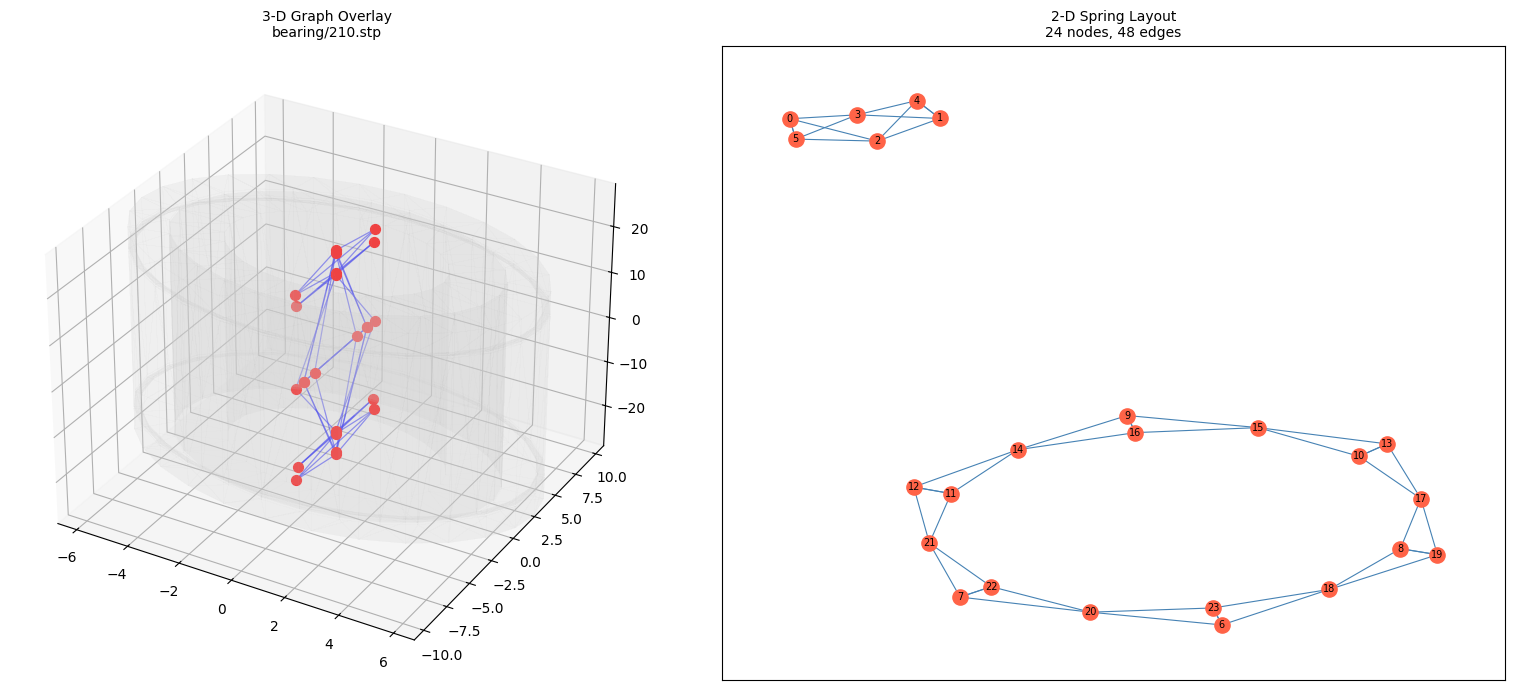

Done: STEP -> B-Rep -> UV-Net DGL Face-Adjacency Graph


In [11]:
fig = plt.figure(figsize=(16, 7))

# ── Left: 3-D overlay ──
ax1 = fig.add_subplot(121, projection="3d")

# Transparent tessellation backdrop
for tris in tessellate_shape(shape):
    if tris:
        ax1.add_collection3d(
            Poly3DCollection(tris, alpha=0.12, facecolor="lightgray",
                             edgecolor="silver", linewidth=0.1)
        )

# Graph nodes
ax1.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2],
            c="red", s=50, zorder=5, depthshade=False)

# Graph edges (draw each undirected edge once)
src_arr, dst_arr = graph.edges()
drawn = set()
for s, d in zip(src_arr.numpy(), dst_arr.numpy()):
    key = (min(s, d), max(s, d))
    if key in drawn:
        continue
    drawn.add(key)
    xs = [centroids[s, 0], centroids[d, 0]]
    ys = [centroids[s, 1], centroids[d, 1]]
    zs = [centroids[s, 2], centroids[d, 2]]
    ax1.plot(xs, ys, zs, "b-", alpha=0.6, linewidth=0.9)

margin = 0.15 * (centroids.max() - centroids.min() + 1e-6)
for i, lab in enumerate("XYZ"):
    getattr(ax1, f"set_{lab.lower()}lim")(
        centroids[:, i].min() - margin, centroids[:, i].max() + margin
    )
ax1.set_title(f"3-D Graph Overlay\n{sample['label']}/{sample['file']}", fontsize=10)

# ── Right: 2-D spring layout ──
ax2 = fig.add_subplot(122)
nxg = dgl.to_networkx(graph).to_undirected()
pos = nx.spring_layout(nxg, seed=SEED)
nx.draw_networkx(
    nxg, pos, ax=ax2, node_size=120, node_color="tomato",
    edge_color="steelblue", width=0.8, font_size=7, with_labels=True,
)
ax2.set_title(f"2-D Spring Layout\n{graph.num_nodes()} nodes, "
              f"{graph.num_edges() // 2} edges", fontsize=10)

plt.tight_layout()
plt.show()

print("Done: STEP -> B-Rep -> UV-Net DGL Face-Adjacency Graph")

# Conclusion

- **What we built**: A pipeline converting CAD STEP files into **face-adjacency DGL graphs** with UV-sampled geometric features (10×10×7 per face, 10×6 per edge)

- **UV-Net connection**: This is the **exact input representation** used by UV-Net (CVPR 2021) - faces as nodes, adjacency as edges, parametric sampling preserving B-Rep precision. The graph can be **directly fed into UV-Net's GNN-CNN hybrid architecture** for training

- **What the graph captures**: **Continuous geometry** (surface/curve samples) + **discrete topology** (face connectivity) + **trim boundaries** (mask channels)

- **ML applications**: Enables **classification** (part type), **segmentation** (feature recognition), **retrieval** (similarity search), and **generation** (design completion) - all tasks UV-Net was designed for

- **GNN training**: Yes, this graph is ready for GNN training - UV-Net specifically uses it to:
  - Encode face grids via CNNs → per-node features
  - Encode edge grids via 1D CNNs → per-edge features
  - Propagate information across the face-adjacency graph via message passing
  - Output predictions for classification, segmentation, or regression tasks

- **Research directions**: Foundation models for CAD, multi-modal learning (text + B-Rep), hierarchical graphs for assemblies, DFM automation, and few-shot learning on engineering datasets